In [1]:
!wget https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/ace_eda_final.csv

--2026-04-26 15:20:47--  https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/ace_eda_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 117008 (114K) [text/plain]
Saving to: ‘ace_eda_final.csv’

ace_eda_final.csv   100%[===================>] 114.27K  --.-KB/s    in 0.004s  

2026-04-26 15:20:47 (30.4 MB/s) - ‘ace_eda_final.csv’ saved [117008/117008]



In [2]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 27.2 MB/s eta 0:00:00


In [3]:
import os
import urllib.request
import sys

import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

import joblib

urls = {
    "features.py" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/src/features.py",
    "model_evaluator.py" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/src/model_evaluator.py",
    "scaffold_split.py" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/src/scaffold_split.py"
}

for filename, url in urls.items():
    if os.path.exists(filename):
        os.remove(filename)
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

sys.path.append('.')

import features
import model_evaluator
import scaffold_split

print("\nSuccess! All modules imported and ready to go.")

Downloaded: features.py
Downloaded: model_evaluator.py
Downloaded: scaffold_split.py

Success! All modules imported and ready to go.


In [4]:
df = pd.read_csv('ace_eda_final.csv')
df.head()

,canonical_smiles,molecule_chembl_id,pIC50,class,MW,LogP,HBD,HBA,TPSA,RotBonds,QED,scaffold
0,C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H...,CHEMBL5420290,7.397940,Active,2113.578,-8.52266,28.0,31.0,811.63,26.0,0.023625,C=C1CNC(=O)CNC(=O)CNC(=O)C2CSCCC(=O)N3CN(CN(C3...
1,CC(=O)CN1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2c...,CHEMBL4159339,6.950782,Active,417.490,3.34480,2.0,4.0,82.00,4.0,0.636535,O=C1Nc2ccccc2C1=NC(=S)NCc1ccc2ccccc2c1
2,CC(=O)C[C@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]3...,CHEMBL5177969,4.947691,Inactive,414.410,1.25962,3.0,8.0,138.20,2.0,0.615058,O=C1CC(=O)c2cccc3c2C1=C1OCCC1C3=O
3,CC(=O)N1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2cc...,CHEMBL4167651,7.971836,Active,403.463,3.30230,2.0,4.0,82.00,2.0,0.641871,O=C1Nc2ccccc2C1=NC(=S)NCc1ccc2ccccc2c1
4,CC(=O)N1CCCC1C(NC(C)C(=O)N1CCCC1C(=O)O)C(=O)O,CHEMBL342652,8.026872,Active,355.391,-0.49580,3.0,5.0,127.25,6.0,0.586183,O=C(CNCC1CCCN1)N1CCCC1


# Feature Engineering

In [5]:
fingerprints = df['canonical_smiles'].apply(lambda x: features.smiles_to_morgan(x, return_as_numpy=True))
X = np.stack(fingerprints.values)

df['class_binary'] = df['class'].map({'Active':1, 'Inactive':0})
y = df['class_binary'].values

print("Shape of X (Feature Matrix):", X.shape)
print("Shape of y (Target Vector):", y.shape)
print("\nClass Distribution:")
print(pd.Series(y).value_counts())
print(pd.Series(y).value_counts(normalize=True))

print("\n...Feature Engineering Complete...")

[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerator
[15:21:20] DEPRECATION WARNING: please use MorganGenerat

Shape of X (Feature Matrix): (553, 2048)
Shape of y (Target Vector): (553,)

Class Distribution:
1    379
0    174
Name: count, dtype: int64
1    0.685353
0    0.314647
Name: proportion, dtype: float64

...Feature Engineering Complete...


[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerator
[15:21:21] DEPRECATION WARNING: please use MorganGenerat

# Phase 1: Random 80-20 Split

In [6]:
# Split 80-20 and stratify to maintain 68.5-31.5 class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (442, 2048)
Shape of X_test: (111, 2048)


In [7]:
# @title
# Applying imbalance Techniques to the Training Data

# Method A: Baseline Model
print(f"Before:\n {pd.Series(y_train).value_counts()}")

# Method B: Class Weighing
# Handled in the model algorithm
# For XGBoost: scale_pos_weight = count(negative examples) / count(positive examples)
weight_ratio = 139/303

# Method C: SMOTE- Synthetic Minority OverSampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE:\n {pd.Series(y_train_smote).value_counts()}")

# Method D: ADASYN (Adaptive Synthetic Sampling)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print(f"After ADASYN:\n {pd.Series(y_train_adasyn).value_counts()}")

# Method E: Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"After:\n {pd.Series(y_train_rus).value_counts()}")

Before:
 1    303
0    139
Name: count, dtype: int64
After SMOTE:
 1    303
0    303
Name: count, dtype: int64
After ADASYN:
 1    303
0    290
Name: count, dtype: int64
After:
 0    139
1    139
Name: count, dtype: int64


In [8]:
# @title
phase_1_configs = [
    {
        "Sampling_Method": "1. Baseline(Imbalanced)",
        "X_train":X_train,
        "y_train":y_train,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }
    },
    {
        "Sampling_Method": "2. Class Weighing",
        "X_train":X_train,
        "y_train":y_train,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=weight_ratio)
        }
    },
    {
        "Sampling_Method": "3. SMOTE",
        "X_train":X_train_smote,
        "y_train":y_train_smote,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }
    },
    {
        "Sampling_Method": "4. ADASYN",
        "X_train":X_train_adasyn,
        "y_train":y_train_adasyn,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }

    },
    {
        "Sampling_Method": "5. Random Undersampling",
        "X_train":X_train_rus,
        "y_train":y_train_rus,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }

    }


]

In [9]:
phase_1_results, phase_1_models = model_evaluator.run_eval_matrix(phase_1_configs, X_test, y_test)
display(phase_1_results)

,Method,Algorithm,F1_Score,Precision,Recall,Confusion Matrix
0,1. Baseline(Imbalanced),Random Forest,0.8881,0.9279,0.8648,"[[26, 9], [1, 75]]"
1,1. Baseline(Imbalanced),XGBoost,0.8940,0.9009,0.8880,"[[29, 6], [4, 72]]"
2,2. Class Weighing,Random Forest,0.8657,0.9034,0.8440,"[[25, 10], [2, 74]]"
3,2. Class Weighing,XGBoost,0.9068,0.9039,0.9100,"[[31, 4], [5, 71]]"
4,3. SMOTE,Random Forest,0.9038,0.9152,0.8945,"[[29, 6], [3, 73]]"
5,3. SMOTE,XGBoost,0.8940,0.9009,0.8880,"[[29, 6], [4, 72]]"
6,4. ADASYN,Random Forest,0.9264,0.9299,0.9231,"[[31, 4], [3, 73]]"
7,4. ADASYN,XGBoost,0.9054,0.9087,0.9023,"[[30, 5], [4, 72]]"
8,5. Random Undersampling,Random Forest,0.8599,0.8495,0.8771,"[[31, 4], [10, 66]]"
9,5. Random Undersampling,XGBoost,0.8708,0.8592,0.8914,"[[32, 3], [10, 66]]"


In the initial Random Split evaluation, synthetic generation techniques like SMOTE and ADASYN appeared to be the top performers, inflating the F1-Scores. However, because Morgan Fingerprints are discrete binary representations of physical structures, I hypothesize that these algorithms achieved high scores by memorizing chemically impossible synthetic data. To prove this, I am advancing to Phase 2 to evaluate these exact same models on a Bemis-Murcko Scaffold Split to test their true out-of-distribution generalization.

# Phase 2: Bemis-Murcko Scaffold Split

In [10]:
train_scaffold_df, test_scaffold_df = scaffold_split.make_scaffold_splits(df=df)

print(f"Total Molecules: {len(df)}")
print(f"Scaffold Train Set: {len(train_scaffold_df)} molecules")
print(f"Scaffold Test Set: {len(test_scaffold_df)} molecules")

Total Molecules: 553
Scaffold Train Set: 412 molecules
Scaffold Test Set: 104 molecules


In [11]:
# Feature Extraction
X_train_scaf = np.stack(train_scaffold_df['canonical_smiles'].apply(lambda x: features.smiles_to_morgan(x, return_as_numpy=True)).values)
y_train_scaf = train_scaffold_df['class_binary'].values

X_test_scaf = np.stack(test_scaffold_df['canonical_smiles'].apply(lambda x: features.smiles_to_morgan(x, return_as_numpy=True)).values)
y_test_scaf = test_scaffold_df['class_binary'].values

print(f"X_train_scaf shape: {X_train_scaf.shape}")
print(f"X_test_scaf shape:  {X_test_scaf.shape}")

[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerator
[15:21:32] DEPRECATION WARNING: please use MorganGenerat

X_train_scaf shape: (412, 2048)
X_test_scaf shape:  (104, 2048)


In [12]:
# @title
# Applying imbalance Techniques to the Training Data

# Method A: Baseline Model
print(f"Before:\n {pd.Series(y_train_scaf).value_counts()}")

# Method B: Class Weighing
# Handled in the model algorithm
# For XGBoost: scale_pos_weight = count(negative examples) / count(positive examples)
active_count_scaf = sum(y_train_scaf == 1)
inactive_count_scaf = sum(y_train_scaf == 0)
scaffold_weight_ratio = inactive_count_scaf / active_count_scaf

# Method C: SMOTE- Synthetic Minority OverSampling
scaf_smote = SMOTE(random_state=42)
X_train_scaf_smote, y_train_scaf_smote = scaf_smote.fit_resample(X_train_scaf, y_train_scaf)
print(f"After SMOTE:\n {pd.Series(y_train_scaf_smote).value_counts()}")

# Method D: ADASYN (Adaptive Synthetic Sampling)
scaf_adasyn = ADASYN(random_state=42)
X_train_scaf_adasyn, y_train_scaf_adasyn = scaf_adasyn.fit_resample(X_train_scaf, y_train_scaf)
print(f"After ADASYN:\n {pd.Series(y_train_scaf_adasyn).value_counts()}")

# Method E: Random Undersampling
scaf_rus = RandomUnderSampler(random_state=42)
X_train_scaf_rus, y_train_scaf_rus = scaf_rus.fit_resample(X_train_scaf, y_train_scaf)
print(f"After Random Undersampling:\n {pd.Series(y_train_scaf_rus).value_counts()}")

Before:
 1    311
0    101
Name: count, dtype: int64
After SMOTE:
 1    311
0    311
Name: count, dtype: int64
After ADASYN:
 1    311
0    300
Name: count, dtype: int64
After Random Undersampling:
 0    101
1    101
Name: count, dtype: int64


In [13]:
# @title
phase_2_configs = [
    {
        "Sampling_Method": "1. Baseline(Imbalanced)",
        "X_train":X_train_scaf,
        "y_train":y_train_scaf,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }
    },
    {
        "Sampling_Method": "2. Class Weighing",
        "X_train":X_train_scaf,
        "y_train":y_train_scaf,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scaffold_weight_ratio)
        }
    },
    {
        "Sampling_Method": "3. SMOTE",
        "X_train":X_train_scaf_smote,
        "y_train":y_train_scaf_smote,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }
    },
    {
        "Sampling_Method": "4. ADASYN",
        "X_train":X_train_scaf_adasyn,
        "y_train":y_train_scaf_adasyn,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }

    },
    {
        "Sampling_Method": "5. Random Undersampling",
        "X_train":X_train_scaf_rus,
        "y_train":y_train_scaf_rus,
        "models": {
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        }

    }


]

In [14]:
phase_2_results, phase_2_models = model_evaluator.run_eval_matrix(phase_2_configs, X_test_scaf, y_test_scaf)
display(phase_2_results)

,Method,Algorithm,F1_Score,Precision,Recall,Confusion Matrix
0,1. Baseline(Imbalanced),Random Forest,0.7249,0.8282,0.7075,"[[16, 20], [2, 66]]"
1,1. Baseline(Imbalanced),XGBoost,0.8224,0.8423,0.8105,"[[25, 11], [5, 63]]"
2,2. Class Weighing,Random Forest,0.6999,0.7946,0.6863,"[[15, 21], [3, 65]]"
3,2. Class Weighing,XGBoost,0.7902,0.7871,0.7941,"[[27, 9], [11, 57]]"
4,3. SMOTE,Random Forest,0.8549,0.8484,0.8644,"[[31, 5], [9, 59]]"
5,3. SMOTE,XGBoost,0.8019,0.7974,0.8080,"[[28, 8], [11, 57]]"
6,4. ADASYN,Random Forest,0.8301,0.8301,0.8301,"[[28, 8], [8, 60]]"
7,4. ADASYN,XGBoost,0.8019,0.7974,0.8080,"[[28, 8], [11, 57]]"
8,5. Random Undersampling,Random Forest,0.8041,0.7981,0.8145,"[[29, 7], [12, 56]]"
9,5. Random Undersampling,XGBoost,0.8041,0.7981,0.8145,"[[29, 7], [12, 56]]"


Random Undersampling despite appearing to be the weakest method initially, proved to be the most chemically robust and reliable model for out-of-distribution generalization

# Model Performance Visualisation

In [15]:
phase_1_results['Split_Type'] = 'Random Split'
phase_2_results['Split_Type'] = 'Bemis-Murcko Scaffold Split'

combined_df = pd.concat([phase_1_results, phase_2_results])

combined_df['Method-Algorithm'] = combined_df['Method'] + ' - ' + combined_df['Algorithm']
display(combined_df)

,Method,Algorithm,F1_Score,Precision,Recall,Confusion Matrix,Split_Type,Method-Algorithm
0,1. Baseline(Imbalanced),Random Forest,0.8881,0.9279,0.8648,"[[26, 9], [1, 75]]",Random Split,1. Baseline(Imbalanced) - Random Forest
1,1. Baseline(Imbalanced),XGBoost,0.8940,0.9009,0.8880,"[[29, 6], [4, 72]]",Random Split,1. Baseline(Imbalanced) - XGBoost
2,2. Class Weighing,Random Forest,0.8657,0.9034,0.8440,"[[25, 10], [2, 74]]",Random Split,2. Class Weighing - Random Forest
3,2. Class Weighing,XGBoost,0.9068,0.9039,0.9100,"[[31, 4], [5, 71]]",Random Split,2. Class Weighing - XGBoost
4,3. SMOTE,Random Forest,0.9038,0.9152,0.8945,"[[29, 6], [3, 73]]",Random Split,3. SMOTE - Random Forest
5,3. SMOTE,XGBoost,0.8940,0.9009,0.8880,"[[29, 6], [4, 72]]",Random Split,3. SMOTE - XGBoost
6,4. ADASYN,Random Forest,0.9264,0.9299,0.9231,"[[31, 4], [3, 73]]",Random Split,4. ADASYN - Random Forest
7,4. ADASYN,XGBoost,0.9054,0.9087,0.9023,"[[30, 5], [4, 72]]",Random Split,4. ADASYN - XGBoost
8,5. Random Undersampling,Random Forest,0.8599,0.8495,0.8771,"[[31, 4], [10, 66]]",Random Split,5. Random Undersampling - Random Forest
9,5. Random Undersampling,XGBoost,0.8708,0.8592,0.8914,"[[32, 3], [10, 66]]",Random Split,5. Random Undersampling - XGBoost


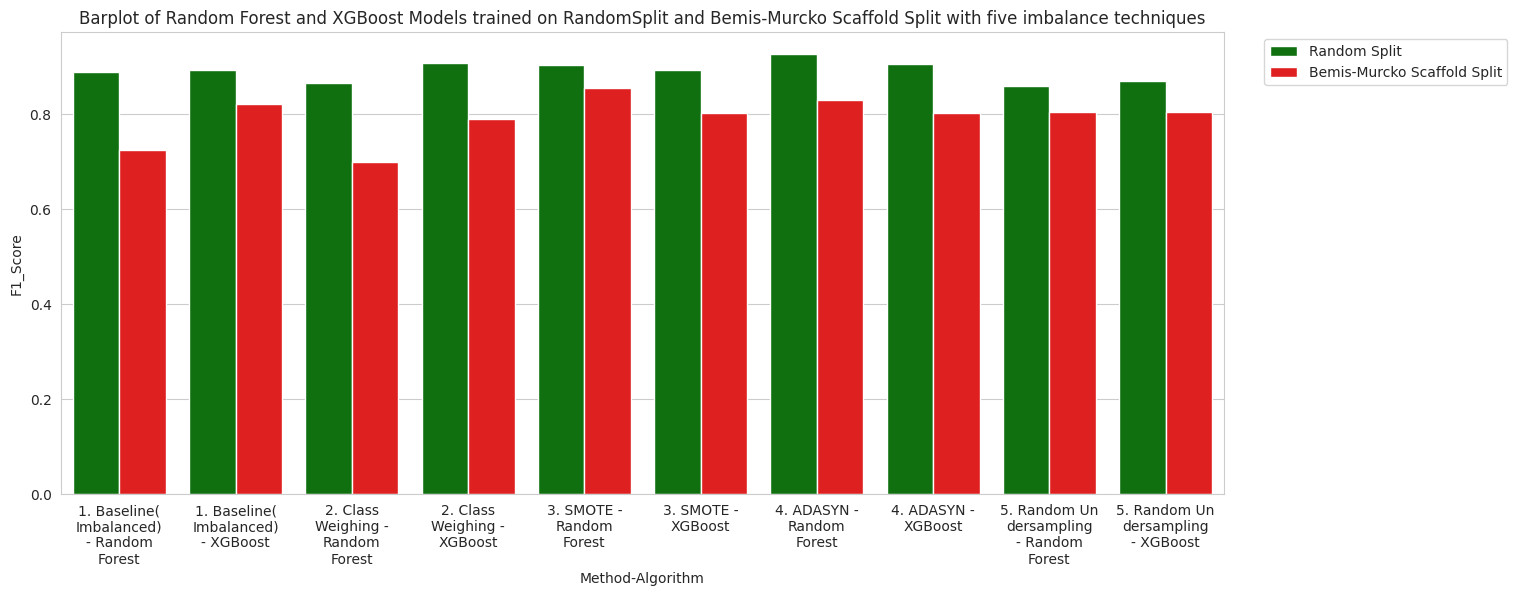

In [16]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(1, figsize=(15, 6))
sns.barplot(data=combined_df, x='Method-Algorithm', y='F1_Score', hue='Split_Type', palette=['green', 'red'], ax=ax)

n_xticks = combined_df['Method-Algorithm'].unique()
ax.set_xticks(range(len(n_xticks)))
ax.set_xticklabels([textwrap.fill(e, 12) for e in n_xticks])
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
ax.set_title('Barplot of Random Forest and XGBoost Models trained on RandomSplit and Bemis-Murcko Scaffold Split with five imbalance techniques')
plt.savefig('rf_and_xgb_barplots.png')
plt.show()

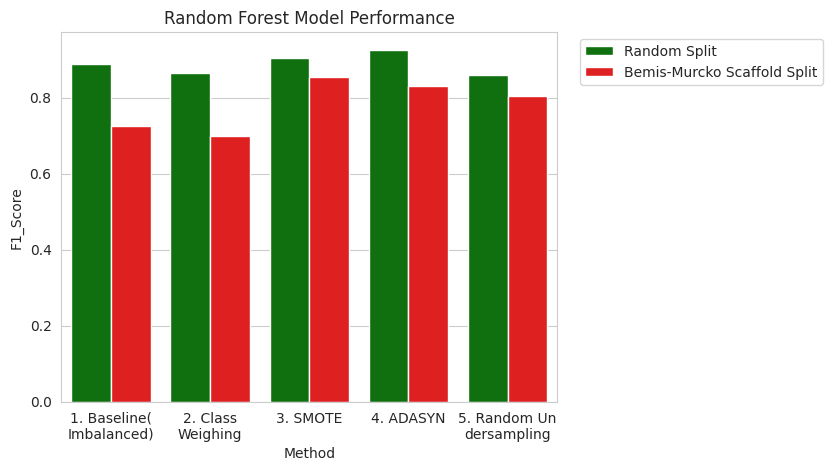

<Figure size 640x480 with 0 Axes>

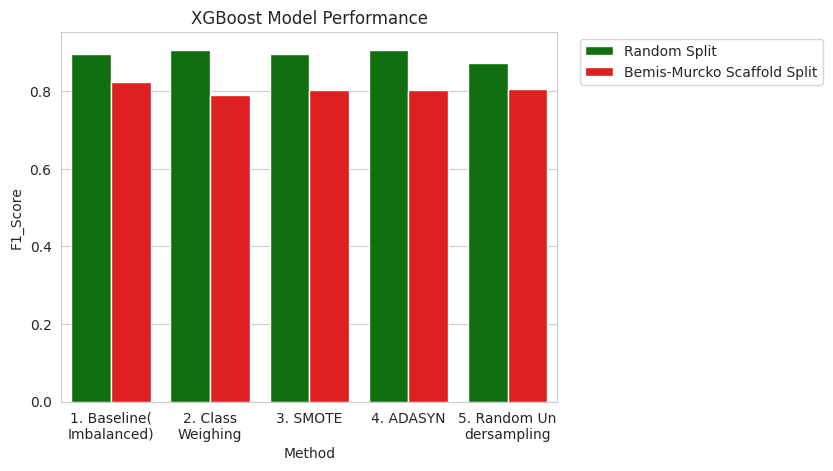

<Figure size 640x480 with 0 Axes>

In [17]:
combined_df = combined_df.drop(columns=['Method-Algorithm'], axis=1)

rf_df = combined_df[combined_df['Algorithm'] == 'Random Forest']
xgb_df = combined_df[combined_df['Algorithm'] == 'XGBoost']
def plot_barplot(df, title):
  sns.set_style('whitegrid')
  fig, ax = plt.subplots(1)
  sns.barplot(data=df, x='Method', y='F1_Score', hue='Split_Type', palette=['green', 'red'], ax=ax)

  n_xticks = df['Method'].unique()
  ax.set_xticks(range(len(n_xticks)))
  ax.set_xticklabels([textwrap.fill(e, 12) for e in n_xticks])
  ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1))
  ax.set_title(title)
  plt.show()

plot_barplot(rf_df, 'Random Forest Model Performance')
plt.savefig('rf_barplot.png')
plot_barplot(xgb_df, 'XGBoost Model Performance')
plt.savefig('xgb_barplot.png')

# Save Model and Data

In [18]:
phase_2_models

{'1. Baseline(Imbalanced)_Random Forest': RandomForestClassifier(random_state=42),
 '1. Baseline(Imbalanced)_XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 '2. Class Weighing_Random Forest': RandomForestClassifier(class_weight='balanced', rando

In [19]:
rus_rf = phase_2_models['5. Random Undersampling_Random Forest']
rus_xgb = phase_2_models['5. Random Undersampling_XGBoost']
joblib.dump(rus_rf, 'rus_rf_model.pkl')
joblib.dump(rus_xgb, 'rus_xgb_model.pkl')
np.save('X_train_scaf_rus.npy', X_train_scaf_rus)
np.save('y_train_scaf_rus.npy', y_train_scaf_rus)